# **Explicação em etapas do que eu fiz para o desafio proposto**

1. Primeiro eu importei a primeira biblioteca "pandas", logo em seguida eu importei o dataset e depois eu dei uma breve vizualização dos dados

In [91]:
import pandas as pd

df = pd.read_csv('alunos.csv', sep=',')
df.head(5)

,id_aluno,idade,sexo,horas_estudo_semana,faltas,nota_prova1,nota_prova2,nota_trabalho,renda_familiar,nivel_escolar_pais,acesso_internet,atividade_extracurricular,aprovado
0,1,20,M,0,4,7.3,8.8,4.2,3046,fundamental,1,0,0
1,2,21,M,12,23,5.1,7.0,5.0,3622,superior,1,1,0
2,3,19,F,9,13,5.3,7.3,7.0,891,medio,1,1,0
3,4,21,F,6,17,3.5,6.7,7.6,1650,superior,1,0,0
4,5,21,M,11,15,5.4,9.1,4.9,2782,fundamental,0,0,0


2. Vi também algumas breves vizualizações sobre as informações do dataset e também a contagem dos valores da futura variavel alvo "**df['aprovado']**"

In [92]:
print(df.info())
print()
print(df.describe())
print()
print(df['aprovado'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_aluno                   2000 non-null   int64  
 1   idade                      2000 non-null   int64  
 2   sexo                       2000 non-null   object 
 3   horas_estudo_semana        2000 non-null   int64  
 4   faltas                     2000 non-null   int64  
 5   nota_prova1                2000 non-null   float64
 6   nota_prova2                2000 non-null   float64
 7   nota_trabalho              2000 non-null   float64
 8   renda_familiar             2000 non-null   int64  
 9   nivel_escolar_pais         2000 non-null   object 
 10  acesso_internet            2000 non-null   int64  
 11  atividade_extracurricular  2000 non-null   int64  
 12  aprovado                   2000 non-null   int64  
dtypes: float64(3), int64(8), object(2)
memory usage:

3. Fiz o pre-processamento dos dados para se adaptar pro modelo que escolhi utilizar, que seria um modelo de classificação

In [93]:
df['sexo'] = df['sexo'].map({'M':0,'F':1})
df['nivel_escolar_pais'] = df['nivel_escolar_pais'].map({'fundamental':0,'medio':1,'superior':2})

4. Selecionei qual seria as features, nesse caso só tirei as colunas que não tinha impacto pro treinamento e a variavel alvo

In [94]:
X = df.drop(['aprovado','id_aluno'], axis=1)
y = df['aprovado']

5. Aqui eu importei a função de treino e teste para o treinamento escolhi 30% para um treino e teste padrão

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

6. Importei o modelo que eu escolhi para o meu objetivo, definir a quantidade de interações que queria que o modelo fizesse pro treino e fiz o proprio treinamento do modelo

In [96]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=2000)

7. Guardei a predição do modelo depois do treinamento

In [97]:
y_pred = model.predict(X_test)

8. Importei a função de acuracia para avaliar o meu modelo, importei a matrix de confusão para ver de uma forma melhor sobres os valores que o meu modelo acertou e errou, importei a função de tranformar a minha matrix de confusão em algo visual.

    Além dos imports eu utilizei as funções para avaliar e plotei o grafico da matrix

Acuracia 0.9233333333333333


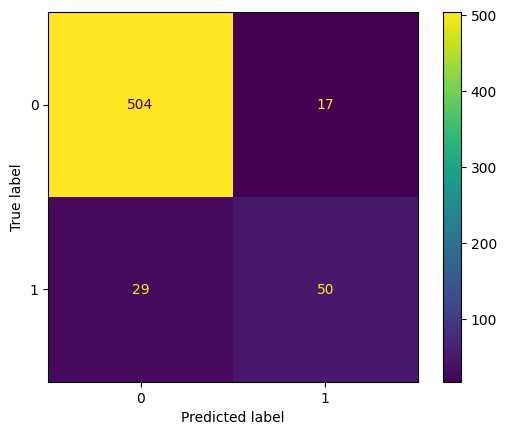

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plot_matriz = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred),display_labels=model.classes_)

print('Acuracia',accuracy_score(y_test,y_pred))
plot_matriz.plot()
plt.show()

9. Quis testar em outros modelos(DecisionTreeClassifier) a ponto de comparação, seguindo os passos do primeiro modelo

Acuracia Árvore: 0.975


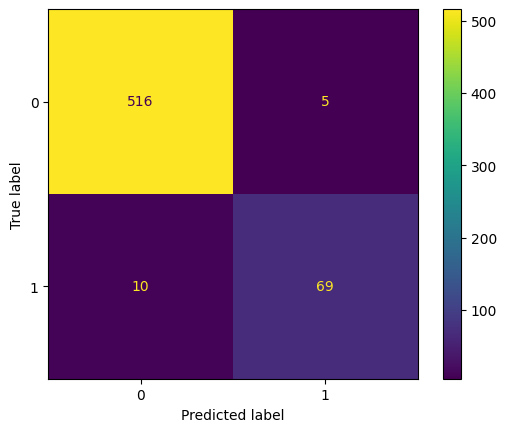

In [99]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier()
modelo_arvore.fit(X_train, y_train)

y_pred_arvore = modelo_arvore.predict(X_test)

plot_matriz_arvore = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_arvore),display_labels=model.classes_)

print('Acuracia Árvore:', accuracy_score(y_test, y_pred_arvore))
plot_matriz_arvore.plot()
plt.show()

10. Trouxe um 3º modelo(RandomForestClassifier) para ter uma comparação mais ampla e novamente, seguindo o fluxo dos 2 primeiros

Acuracia RF: 0.9733333333333334


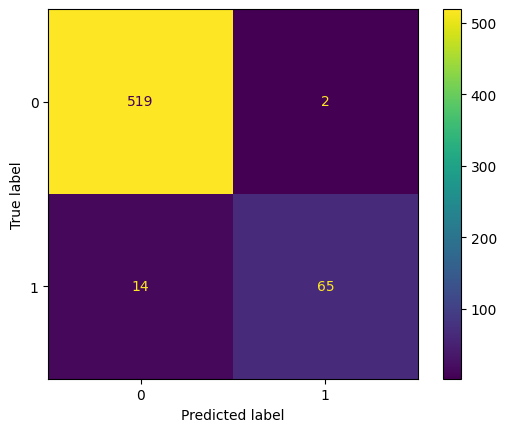

In [100]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier()
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

plot_matriz_rf = ConfusionMatrixDisplay(confusion_matrix(y_test,y_pred_rf),display_labels=model.classes_)

print("Acuracia RF:", accuracy_score(y_test, y_pred_rf))
plot_matriz_rf.plot()
plt.show()

11. Plotei o nivel de importacias das features dos 3 modelos testados

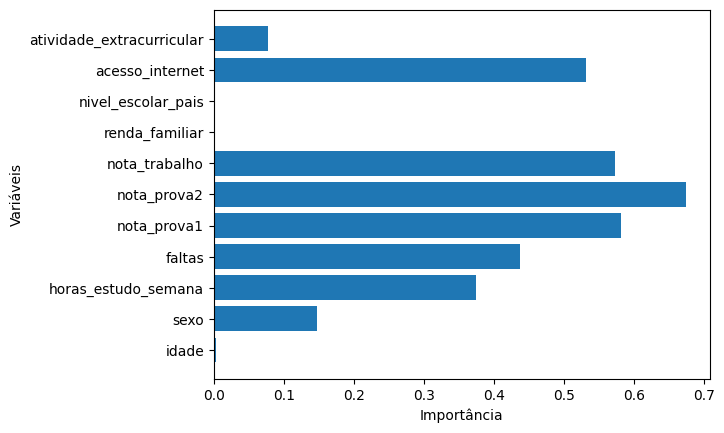

In [101]:
importancias_1 = abs(model.coef_[0])

plt.barh(X.columns, importancias_1)
plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.show()

12. Modelo(DecisionTreeClassifier)

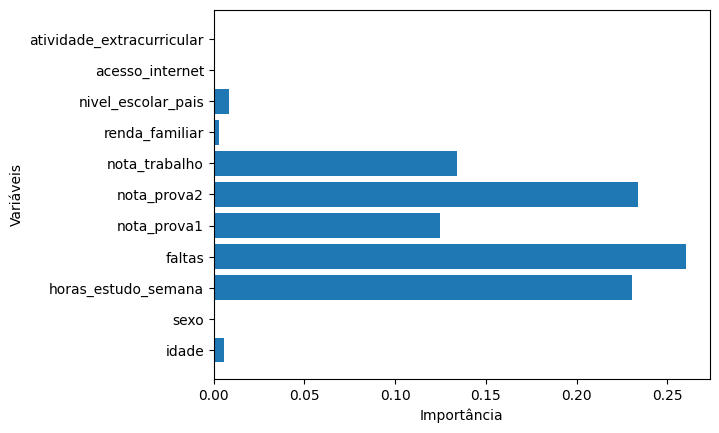

In [102]:
importancias_2 = modelo_arvore.feature_importances_

plt.barh(X.columns, importancias_2)
plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.show()

13. Modelo(RandomForestClassifier)

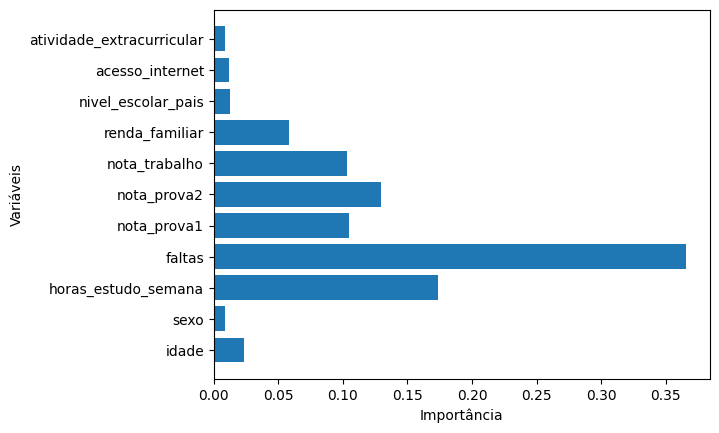

In [103]:
importancias_3 = modelo_rf.feature_importances_

plt.barh(X.columns, importancias_3)
plt.xlabel("Importância")
plt.ylabel("Variáveis")
plt.show()

14. Trouxe novos dados para testar a previsão do modelo na pratica

In [104]:
df_novo = pd.read_csv('novos_dados.csv',sep=';')
df_novo

,id_aluno,idade,sexo,horas_estudo_semana,faltas,nota_prova1,nota_prova2,nota_trabalho,renda_familiar,nivel_escolar_pais,acesso_internet,atividade_extracurricular
0,2001,17,0,3,10,4.8,7.8,9.8,1572,1,1,1
1,2002,17,0,2,0,7.2,5.7,7.8,2088,0,1,0
2,2003,20,0,13,8,8.2,4.0,5.1,3980,2,1,0
3,2004,17,1,11,21,4.4,9.2,8.0,2394,2,1,0
4,2005,19,1,7,7,5.3,7.5,5.5,922,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,2996,20,1,7,16,6.6,5.0,7.9,1219,0,0,0
996,2997,18,0,4,19,4.4,9.3,7.5,1803,2,1,0
997,2998,20,0,13,7,7.0,9.1,4.5,2562,2,0,0
998,2999,22,1,2,21,7.0,4.5,4.5,3419,1,1,0


15. Fiz um rapida features para fazer a predição com o primeiro modelo

In [105]:
X_novo = df_novos.drop(['id_aluno','prvisoes'],axis=1)

prev_novo = model.predict(X_novo)

16. Plotei um grafico para analisar a previsão que o modelo fez

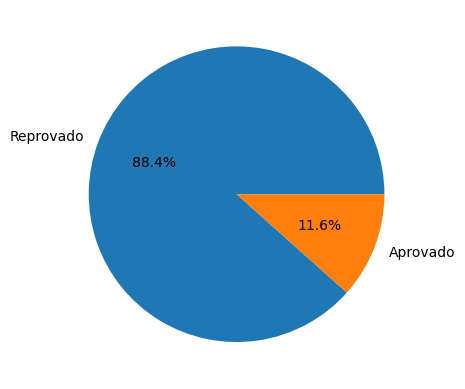

In [106]:
df_novo['previsoes'] = prev_novo

df_novo['previsoes'] = df_novo['previsoes'].map({0:'Reprovado',1:'Aprovado'})

relatorio_dados_novo = df_novo['previsoes'].value_counts()

plt.pie(relatorio_dados_novo, labels=relatorio_dados_novo.index, autopct='%1.1f%%')
plt.show()

17. Repliquei para o outro modelo(DecisionTreeClassifier)

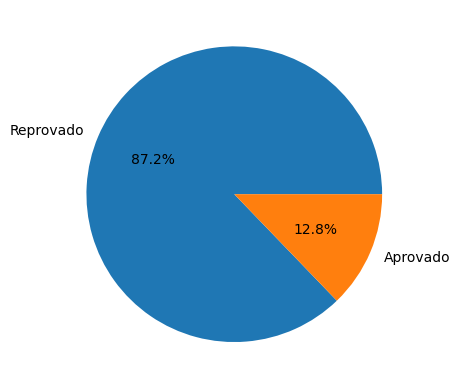

In [107]:
prev_novo_arvore = modelo_arvore.predict(X_novo)

df_novo['previsoes'] = prev_novo_arvore

df_novo['previsoes'] = df_novo['previsoes'].map({0:'Reprovado',1:'Aprovado'})

relatorio_dados_novo = df_novo['previsoes'].value_counts()

plt.pie(relatorio_dados_novo, labels=relatorio_dados_novo.index, autopct='%1.1f%%')
plt.show()

18. E repliquei para o 3º modelo(RandomForestClassifier)

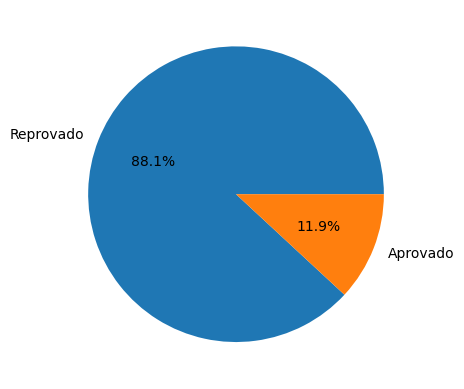

In [108]:
prev_novo_rf = modelo_rf.predict(X_novo)

df_novo['previsoes'] = prev_novo_rf

df_novo['previsoes'] = df_novo['previsoes'].map({0:'Reprovado',1:'Aprovado'})

relatorio_dados_novo = df_novo['previsoes'].value_counts()

plt.pie(relatorio_dados_novo, labels=relatorio_dados_novo.index, autopct='%1.1f%%')
plt.show()

19. Conclusão das analises:

    Apesar de utilizar 3 modelos diferentes para o mesmo dataset e os novos dados. A tendencia do surgimento dos alunos aprovados é extremamente baixa e isso se deve pela grande quantidade de faltas, não necessariamente apenas isso, porem é oque mais se destaca diantes de outras features